The goal of this notebook is to train a machine learning model to prioritize Mass2Motifs based on their relevance (the probability of representing an actual substructure). 

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pickle


The excel file that is used as input for the model was created with the same logic as feature_parsing. It contains the manually curated Mass2Motifs that were handpicked and labeled for each of the three classes (0.1, 0.5, and 0.9).
In total 69 Mass2Motifs were used:
- 33 labeled as 0.1
- 20 labeled as 0.5
- 16 labeled as 0.9

In [2]:
motif_features = pd.read_excel("/home/ioannis/thesis_data/ML/motif_features_ML.xlsx")
print(motif_features.head())

  motif_id     intra     inter  mcs_size  mcs_support  n_peaks  n_spectra  \
0   91_400  0.015868  0.344764         7     0.554217        1         83   
1   38_400  0.051209  0.500000         6     0.763158        2         38   
2   43_400  0.577539  0.415385        13     0.753333        1        150   
3  176_400  0.020690  0.322222         7     0.733333        1         30   
4  153_400  0.730739  0.630657        31     0.535519        2        183   

   peak_mean  peak_std  peak_min  peak_max  label  
0   0.927711  0.000000  0.927711  0.927711    0.9  
1   0.723684  0.065789  0.657895  0.789474    0.5  
2   0.873333  0.000000  0.873333  0.873333    0.9  
3   0.700000  0.000000  0.700000  0.700000    0.5  
4   0.483607  0.303279  0.180328  0.786885    0.5  


As predictive features only numerical values should be considered, in order for the model not be exposed in specific information like the motif_id.

In [3]:
X = motif_features.drop(columns=['motif_id', 'label'])
y = motif_features['label']

Stratified KFold is used in order to preserve the balance of each class in each fold. Especially in this case, where the number of Mass2Motifs in the dataset is low, stratification is necessairy to get reliable results in each fold.

In [4]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_strat = motif_features["label"].astype(str)   # used only for stratification


Spearman correlation and Mean Absolute Error (MAE) are used as evaluation metrics. Spearman correlation evaluates the correctness of the ranking order, and MAE the deviation of the predicted score from the true label (0.1, 0.5, 0.9).

In [5]:
spearman_scores = []
mae_scores = []

all_true = []
all_pred = []
all_ids = []

for train_idx, test_idx in skf.split(X, y_strat):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = RandomForestRegressor(
        n_estimators=500,
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # store predictions for plotting later
    all_true.extend(y_test)
    all_pred.extend(y_pred)

    # ranking metric
    spearman = spearmanr(y_test, y_pred).correlation
    spearman_scores.append(spearman)

    # regression metric
    mae = mean_absolute_error(y_test, y_pred)
    mae_scores.append(mae)

    # store motif IDs for the test fold
    motif_ids_test = motif_features.iloc[test_idx]["motif_id"]
    all_ids.extend(motif_ids_test)


In [6]:
print("Spearman correlation per fold:", spearman_scores)
print("Mean Spearman:", np.mean(spearman_scores))

print("\nMAE per fold:", mae_scores)
print("Mean MAE:", np.mean(mae_scores))

Spearman correlation per fold: [0.8626053049268316, 0.9198662110077999, 0.9031413708076581, 0.7406714945777089, 0.9302605094190635]
Mean Spearman: 0.8713089781478125

MAE per fold: [0.14245714285714323, 0.08314285714285775, 0.13885714285714307, 0.1626285714285714, 0.10640000000000084]
Mean MAE: 0.12669714285714326


In [7]:
# Convert to numpy arrays
spearman_scores = np.array(spearman_scores)
mae_scores = np.array(mae_scores)

# Summary statistics
spearman_mean = spearman_scores.mean()
spearman_sd = spearman_scores.std(ddof=1)   # sample SD and not population SD

mae_mean = mae_scores.mean()
mae_sd = mae_scores.std(ddof=1)             # sample SD and not population SD

print("Spearman correlations:", spearman_scores)
print(f"Mean Spearman: {spearman_mean:.3f} ± {spearman_sd:.3f}")

print("MAE scores:", mae_scores)
print(f"Mean MAE: {mae_mean:.3f} ± {mae_sd:.3f}")


Spearman correlations: [0.8626053  0.91986621 0.90314137 0.74067149 0.93026051]
Mean Spearman: 0.871 ± 0.077
MAE scores: [0.14245714 0.08314286 0.13885714 0.16262857 0.1064    ]
Mean MAE: 0.127 ± 0.032


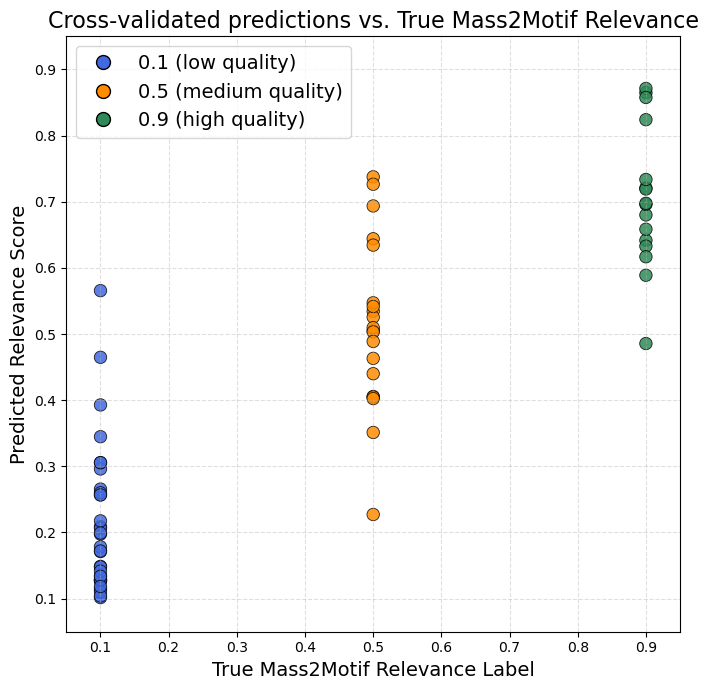

In [8]:
# Convert to arrays
true_vals = np.array(all_true)
pred_vals = np.array(all_pred)

# Add small jitter to x-axis (true labels)
rng = np.random.default_rng(42)
x_jittered = true_vals + rng.normal(0, 0.01, size=len(true_vals))

# Color map for classes
colors = {0.1: "royalblue", 0.5: "darkorange", 0.9: "seagreen"}
point_colors = [colors[val] for val in true_vals]

plt.figure(figsize=(7,7))

# Scatter plot
plt.scatter(
    true_vals,
    pred_vals,
    c=point_colors,
    alpha=0.85,
    edgecolor="black",
    linewidth=0.6,
    s=80
)

# Labels and title
plt.xlabel("True Mass2Motif Relevance Label", fontsize=14)
plt.ylabel("Predicted Relevance Score", fontsize=14)
plt.title("Cross‑validated predictions vs. True Mass2Motif Relevance", fontsize=16)

# Grid and limits
plt.grid(True, linestyle="--", alpha=0.4)
plt.xlim(0.05, 0.95)
plt.ylim(0.05, 0.95)

# Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='0.1 (low quality)',
           markerfacecolor='royalblue', markersize=10, markeredgecolor='black'),
    Line2D([0], [0], marker='o', color='w', label='0.5 (medium quality)',
           markerfacecolor='darkorange', markersize=10, markeredgecolor='black'),
    Line2D([0], [0], marker='o', color='w', label='0.9 (high quality)',
           markerfacecolor='seagreen', markersize=10, markeredgecolor='black')
]
plt.legend(handles=legend_elements, loc="upper left", frameon=True, fontsize=14)

plt.tight_layout()
plt.show()


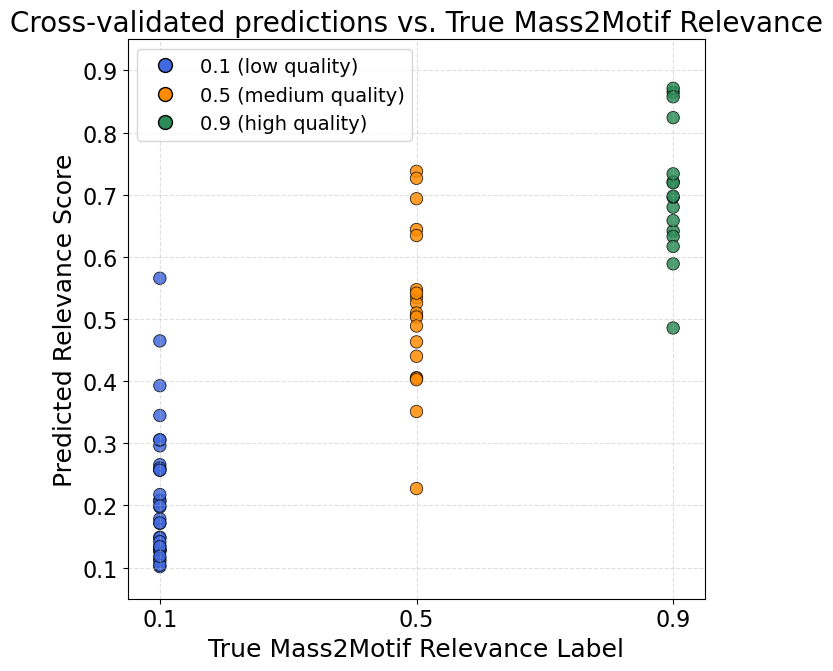

In [14]:
plt.figure(figsize=(7,7))

plt.scatter(
    true_vals,
    pred_vals,
    c=point_colors,
    alpha=0.85,
    edgecolor="black",
    linewidth=0.6,
    s=80
)

# Force x-axis ticks at 0.1, 0.5, 0.9 and enlarge them
plt.xticks([0.1, 0.5, 0.9], fontsize=16)

# Enlarge y-axis tick labels
plt.yticks(fontsize=16)

# Enlarge axis labels
plt.xlabel("True Mass2Motif Relevance Label", fontsize=18)
plt.ylabel("Predicted Relevance Score", fontsize=18)

# Enlarge title (optional)
plt.title("Cross‑validated predictions vs. True Mass2Motif Relevance", fontsize=20)

plt.grid(True, linestyle="--", alpha=0.4)
plt.xlim(0.05, 0.95)
plt.ylim(0.05, 0.95)

plt.legend(handles=legend_elements, loc="upper left", frameon=True, fontsize=14)

plt.tight_layout()
plt.show()


In [9]:
results_df = pd.DataFrame({
    "motif_id": all_ids,
    "true_label": all_true,
    "predicted_score": all_pred
}).sort_values("predicted_score", ascending=False)
results_df
results_df.to_excel("cv_predictions_with_ids_final.xlsx", index=False)

In [10]:
from sklearn.ensemble import RandomForestRegressor

final_model = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

final_model.fit(X, y)

,n_estimators,500
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
importances = final_model.feature_importances_
feature_names = X.columns

for name, imp in sorted(zip(feature_names, importances), key=lambda x: -x[1]):
    print(f"{name}: {imp:.3f}")

peak_max: 0.293
mcs_support: 0.212
mcs_size: 0.148
peak_mean: 0.127
intra: 0.081
n_spectra: 0.054
peak_min: 0.032
n_peaks: 0.020
inter: 0.018
peak_std: 0.015


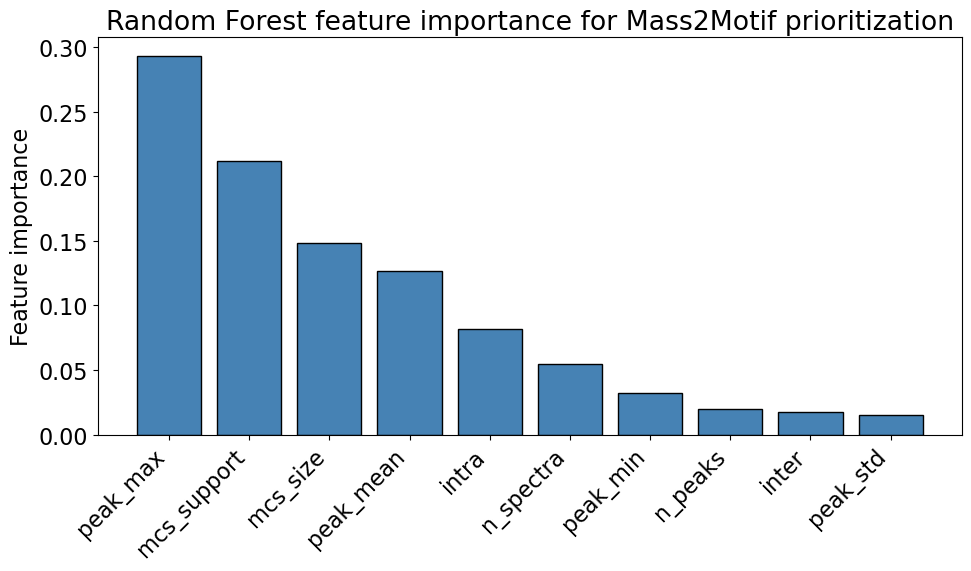

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Increase all font sizes globally
plt.rcParams.update({'font.size': 16})

# Sort features by importance
indices = np.argsort(importances)[::-1]
sorted_names = feature_names[indices]
sorted_importances = importances[indices]

plt.figure(figsize=(10, 6))
plt.bar(range(len(sorted_importances)), sorted_importances,
        color="steelblue", edgecolor="black")

plt.xticks(range(len(sorted_importances)), sorted_names,
           rotation=45, ha="right")
plt.ylabel("Feature importance")
plt.title("Random Forest feature importance for Mass2Motif prioritization")

plt.tight_layout()
plt.show()



In [51]:
with open("motif_priority_model.pkl", "wb") as f:
    pickle.dump(final_model, f)